In [85]:
# Imports 

import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, norm
from matplotlib import pyplot as plt
import time

In [86]:
# Directories and Global Variables
DATA_DIRECTORY = "./results"

# Retreive all Directories and files in the results 
QUALITY_DIRECTORIES = os.listdir(DATA_DIRECTORY)

In [87]:
files = []
for q in QUALITY_DIRECTORIES: 
    runs = os.listdir(f"{DATA_DIRECTORY}/{q}")
    for f in runs: 
        files.append(f"{q}/{f}")
files

['all-off/run_02.csv',
 'all-off/run_03.csv',
 'all-off/run_06.csv',
 'all-off/run_09.csv',
 'all-off/run_101.csv',
 'all-off/run_102.csv',
 'all-off/run_105.csv',
 'all-off/run_107.csv',
 'all-off/run_112.csv',
 'all-off/run_114.csv',
 'all-off/run_115.csv',
 'all-off/run_120.csv',
 'all-off/run_14.csv',
 'all-off/run_24.csv',
 'all-off/run_29.csv',
 'all-off/run_46.csv',
 'all-off/run_50.csv',
 'all-off/run_62.csv',
 'all-off/run_70.csv',
 'all-off/run_72.csv',
 'all-off/run_79.csv',
 'all-off/run_81.csv',
 'all-off/run_83.csv',
 'all-off/run_84.csv',
 'all-off/run_88.csv',
 'all-off/run_90.csv',
 'all-off/run_92.csv',
 'all-off/run_94.csv',
 'all-off/run_98.csv',
 'all-off/run_99.csv',
 'ambient-mode/run_08.csv',
 'ambient-mode/run_11.csv',
 'ambient-mode/run_111.csv',
 'ambient-mode/run_117.csv',
 'ambient-mode/run_118.csv',
 'ambient-mode/run_119.csv',
 'ambient-mode/run_13.csv',
 'ambient-mode/run_15.csv',
 'ambient-mode/run_16.csv',
 'ambient-mode/run_19.csv',
 'ambient-mode/run

In [88]:
example = pd.read_csv(f"{DATA_DIRECTORY}/{files[0]}")[['Time', 'SYSTEM_POWER (Watts)']]
first_time = example['Time'].iloc[0]
example['Time'] = example['Time'].apply(lambda x: (x - first_time) / 1000)
example.head(10)

,Time,SYSTEM_POWER (Watts)
0,0.000,4.246744
1,0.000,4.246744
2,0.200,4.246744
3,0.402,4.246744
4,0.607,4.246744
5,0.809,2.657088
6,1.014,2.657088
7,1.215,2.657088
8,1.419,2.657088
9,1.624,2.657088


In [89]:
# Check whether Data is normal

stats, p_val = shapiro(example['SYSTEM_POWER (Watts)'])

print(f"With p-val {p_val}, the data is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}")

With p-val 1.9113066844221772e-17, the data is NOT NORMAL


In [90]:
# Normalising the data

mean = example['SYSTEM_POWER (Watts)'].mean()
std = example['SYSTEM_POWER (Watts)'].std()
outlier = []
max_diff = 0
print(f"std: {3 * std}")
for idx, val in enumerate(example['SYSTEM_POWER (Watts)']): 
    diff = mean - val
    if np.abs(diff) > max_diff: max_diff = np.abs(diff) 
    if np.abs(diff) > 3*std: 
        print(f"Found outlier at {idx}")
        outlier.append(idx)

print(max_diff)
normalised_example = example.drop(index=outlier) 
normalised_example   


std: 1.134349841505006
Found outlier at 0
Found outlier at 1
Found outlier at 2
Found outlier at 3
Found outlier at 4
1.7372316764259979


,Time,SYSTEM_POWER (Watts)
5,0.809,2.657088
6,1.014,2.657088
7,1.215,2.657088
8,1.419,2.657088
9,1.624,2.657088
...,...,...
292,59.301,2.700701
293,59.506,2.700701
294,59.709,2.700701
295,59.914,2.061238


Text(0, 0.5, 'System Power measurement (Watts)')

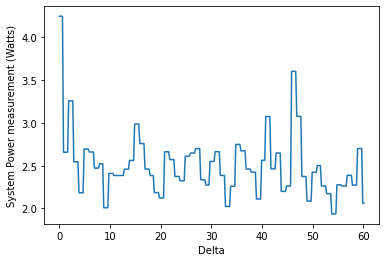

In [91]:
#Plotting data distribution
plt.plot(example['Time'], example['SYSTEM_POWER (Watts)'])
plt.xlabel("Delta")
plt.ylabel("System Power measurement (Watts)")

{'bodies': [<matplotlib.collections.PolyCollection at 0x1e0b89a0430>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x1e0b89a0d00>,
 'cmins': <matplotlib.collections.LineCollection at 0x1e0b89a0040>,
 'cbars': <matplotlib.collections.LineCollection at 0x1e0b8d768c0>}

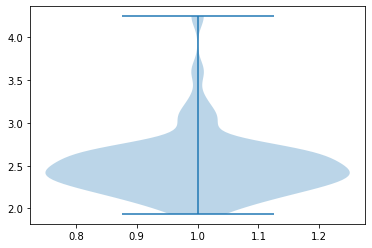

In [92]:
# Violin plots

plt.violinplot(example['SYSTEM_POWER (Watts)'])


### Creating a general setup to create combinations by subcategories 

The outlier removal didn't work, possibly becasue there are not enough sample. Might have to do something else. 

In [93]:
dataframes = {}
for f in files: 
    print(f"======== Converting file '{f}' ========")
    df = pd.read_csv(f"{DATA_DIRECTORY}/{f}")[['Time', 'SYSTEM_POWER (Watts)']]
    first_time = df['Time'].iloc[0]
    df['Time'] = df['Time'].apply(lambda x: (x - first_time) / 1000)
    dataframes[f] = df
    
dataframes[f]

======== Converting file 'all-off/run_02.csv' ========
======== Converting file 'all-off/run_03.csv' ========
======== Converting file 'all-off/run_06.csv' ========
======== Converting file 'all-off/run_09.csv' ========
======== Converting file 'all-off/run_101.csv' ========
======== Converting file 'all-off/run_102.csv' ========
======== Converting file 'all-off/run_105.csv' ========
======== Converting file 'all-off/run_107.csv' ========
======== Converting file 'all-off/run_112.csv' ========
======== Converting file 'all-off/run_114.csv' ========
======== Converting file 'all-off/run_115.csv' ========
======== Converting file 'all-off/run_120.csv' ========
======== Converting file 'all-off/run_14.csv' ========
======== Converting file 'all-off/run_24.csv' ========
======== Converting file 'all-off/run_29.csv' ========
======== Converting file 'all-off/run_46.csv' ========
======== Converting file 'all-off/run_50.csv' ========
======== Converting file 'all-off/run_62.csv' ========
==

,Time,SYSTEM_POWER (Watts)
0,0.000,6.391113
1,0.000,6.391113
2,0.208,6.391113
3,0.419,2.233296
4,0.626,2.233296
...,...,...
287,59.237,2.812572
288,59.442,2.006195
289,59.652,2.006195
290,59.856,2.006195


In [94]:
for f, df in dataframes.items():
    stats, p_val = shapiro(df['SYSTEM_POWER (Watts)'])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.9113066844221772e-17, the data in all-off/run_02.csv is NOT NORMAL
With p-val 4.6881137169551e-29, the data in all-off/run_03.csv is NOT NORMAL
With p-val 1.1864222729290007e-29, the data in all-off/run_06.csv is NOT NORMAL
With p-val 1.6534177404992079e-07, the data in all-off/run_09.csv is NOT NORMAL
With p-val 6.451413923866524e-29, the data in all-off/run_101.csv is NOT NORMAL
With p-val 1.5325591538395714e-25, the data in all-off/run_102.csv is NOT NORMAL
With p-val 2.4833479963313448e-28, the data in all-off/run_105.csv is NOT NORMAL
With p-val 1.190043258247897e-05, the data in all-off/run_107.csv is NOT NORMAL
With p-val 1.6449727803910982e-27, the data in all-off/run_112.csv is NOT NORMAL
With p-val 1.9700250111776008e-11, the data in all-off/run_114.csv is NOT NORMAL
With p-val 8.046837738836451e-30, the data in all-off/run_115.csv is NOT NORMAL
With p-val 3.622641068582468e-25, the data in all-off/run_120.csv is NOT NORMAL
With p-val 1.2461416934134641e-26, the 

In [95]:
normalised_dataframes = {}
for f, df in dataframes.items(): 
    mean = df['SYSTEM_POWER (Watts)'].mean()
    std = df['SYSTEM_POWER (Watts)'].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(df['SYSTEM_POWER (Watts)']): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = df.drop(index=outlier) 
    normalised_dataframes[f] = n_df
    print("===============================================")

3x std: 1.134349841505006 | mean: 2.509512479457791
Found outlier at 0
Found outlier at 1
Found outlier at 2
Found outlier at 3
Found outlier at 4
Maximum difference found: 1.7372316764259979
3x std: 2.172075296704582 | mean: 2.560026745603542
Found outlier at 0
Found outlier at 1
Maximum difference found: 7.565638919069309
3x std: 1.7711237292219826 | mean: 2.3857805308413833
Found outlier at 0
Found outlier at 1
Maximum difference found: 6.254865449993577
3x std: 0.9280422313851784 | mean: 2.3631866129293835
Maximum difference found: 0.9080998746499622
3x std: 1.862513045369197 | mean: 2.3632804833046377
Found outlier at 0
Found outlier at 1
Maximum difference found: 6.496374896944386
3x std: 1.6729590831528658 | mean: 2.363048655529545
Found outlier at 0
Found outlier at 1
Found outlier at 2
Found outlier at 3
Maximum difference found: 3.7725976877016563
3x std: 2.0234872317410413 | mean: 2.5062457612932545
Found outlier at 0
Found outlier at 1
Maximum difference found: 6.8689325758

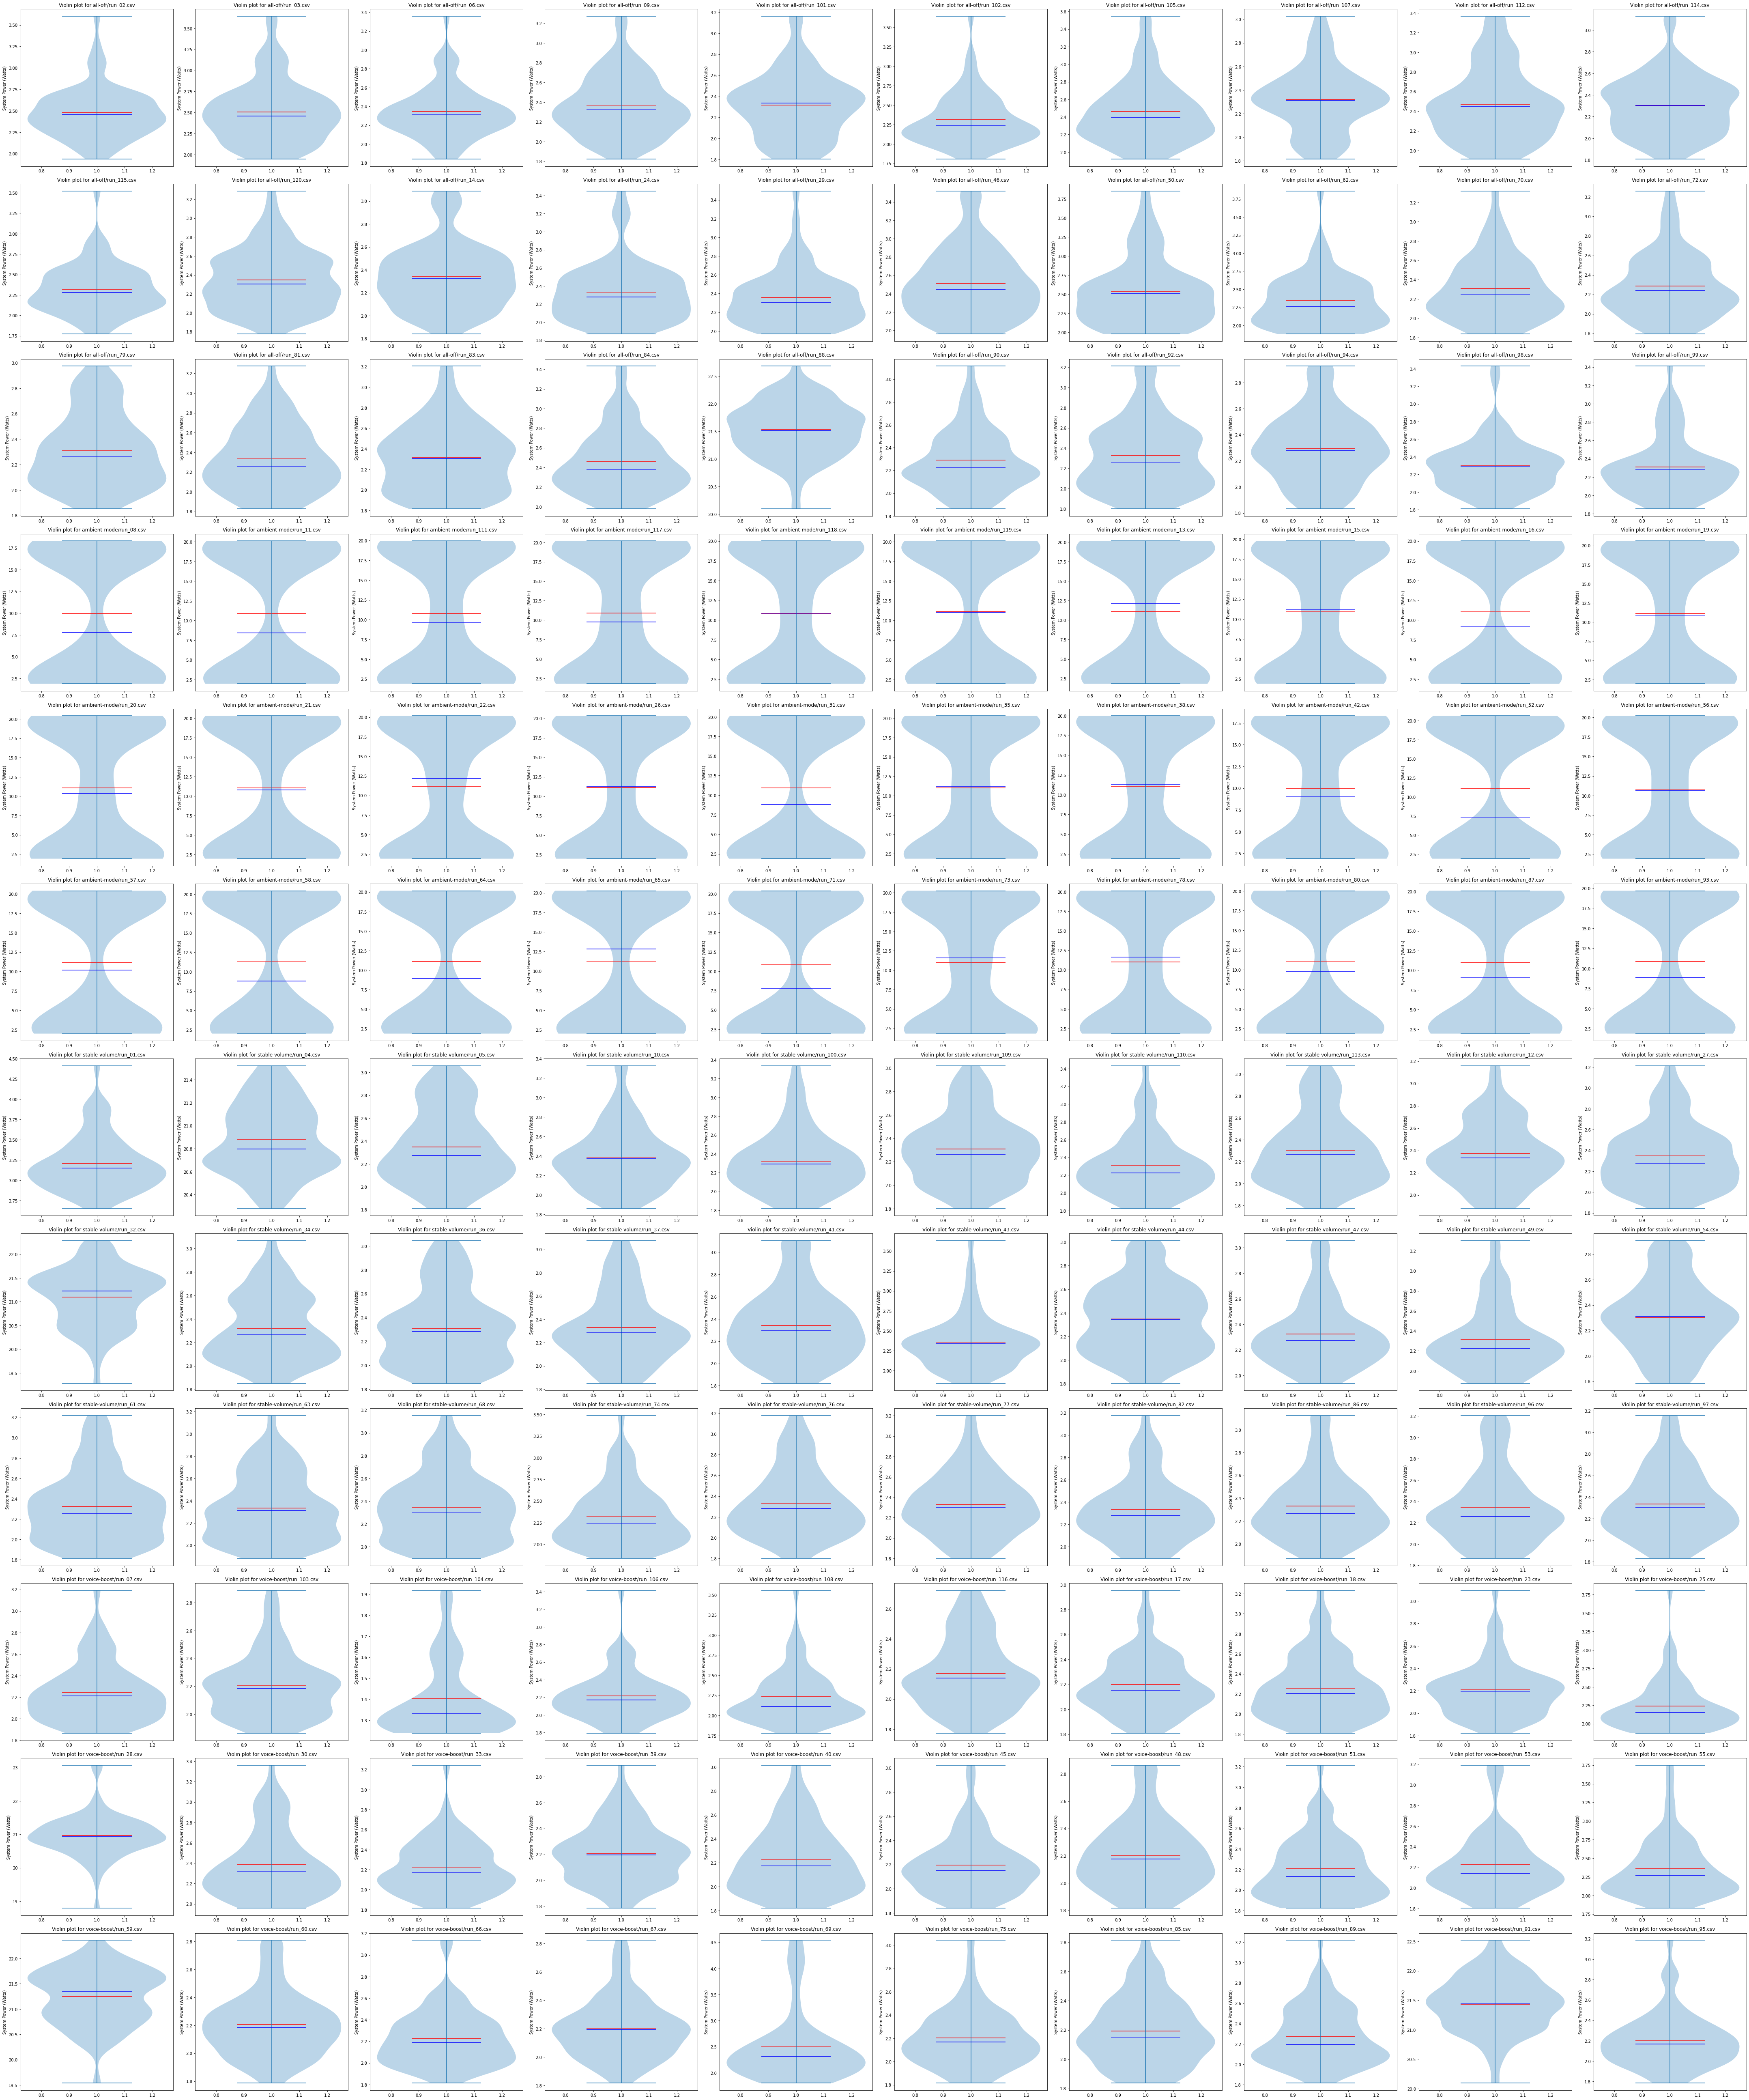

In [96]:
fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
                               figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(df['SYSTEM_POWER (Watts)'], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

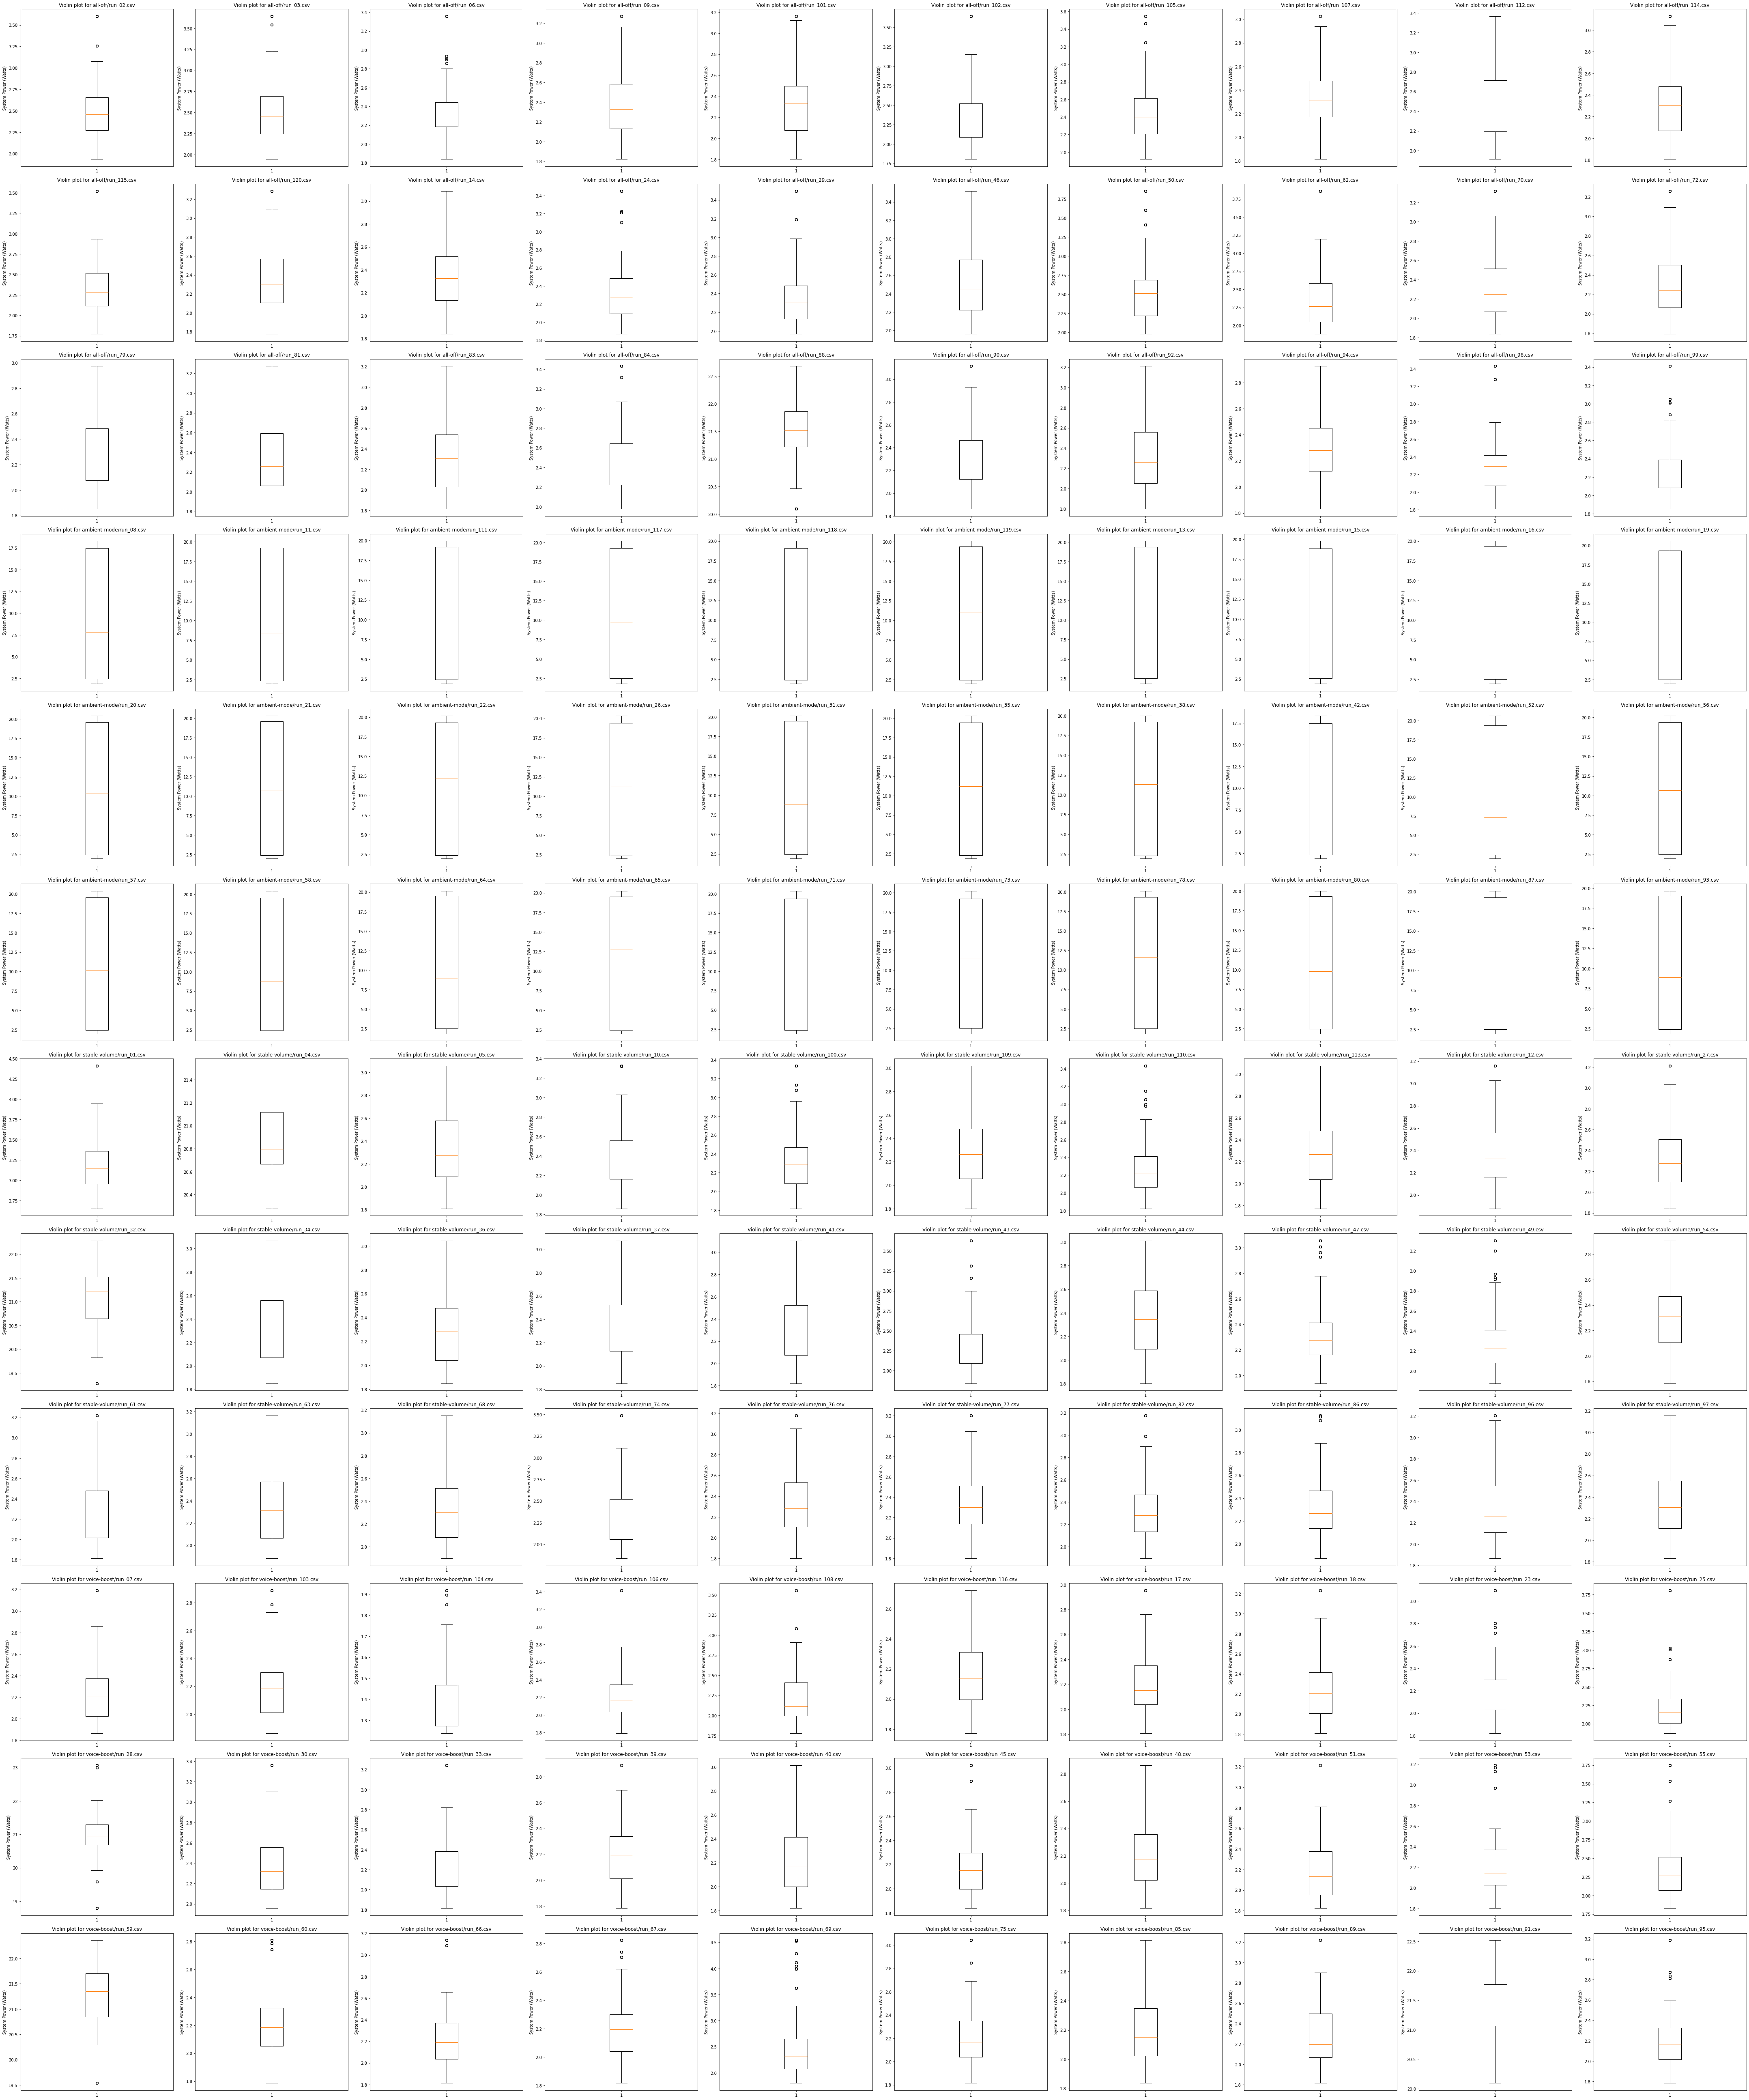

In [97]:
fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
                               figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(df['SYSTEM_POWER (Watts)'])
    
plt.tight_layout()
plt.show()

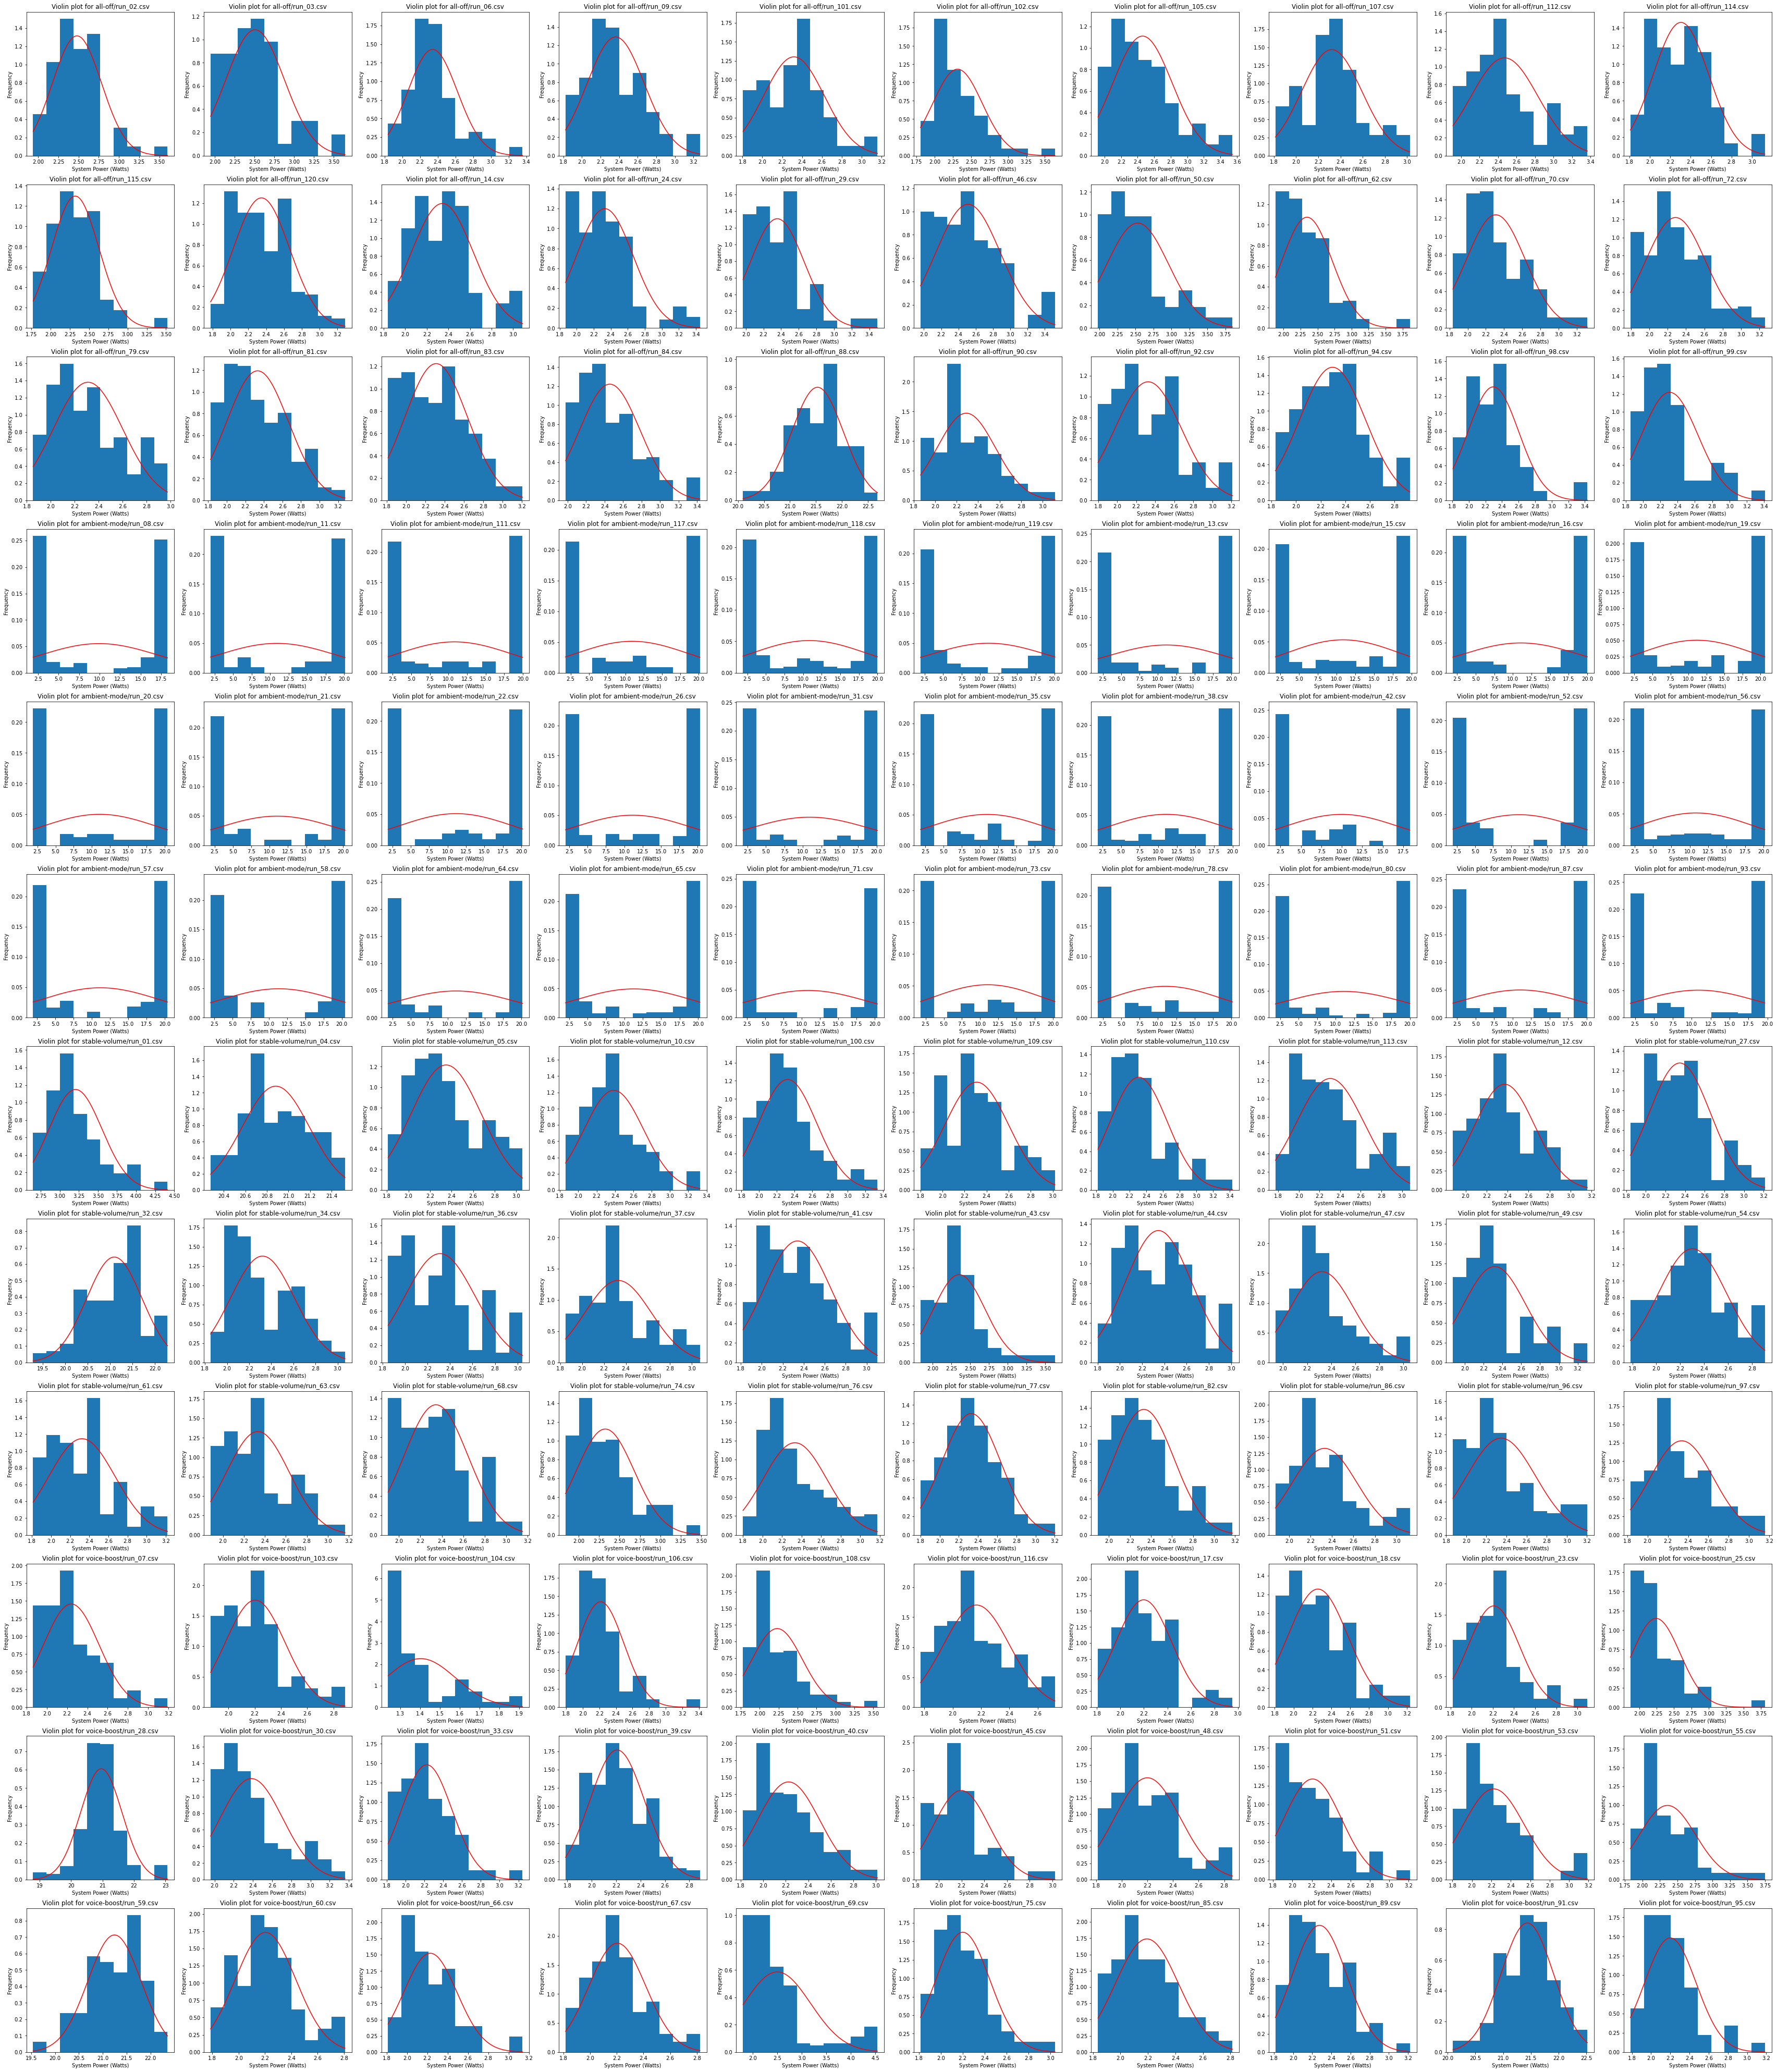

In [194]:
fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
                               figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
    mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
    x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

In [ ]:
fig, plots = plt.subplots(nrows = 3 * len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3,
                               figsize =(6 * len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")) // 3, 6 * len(QUALITY_DIRECTORIES) * 3),
                               sharey = True)
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
    mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
    x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

# Exploring Results - Avearges & Medians

## Initial Average results

In [99]:
res = {}
for dir in QUALITY_DIRECTORIES: res[dir] = []
for file, df in dataframes.items(): 
    average = df['SYSTEM_POWER (Watts)'].mean()
    f = file.split("/")[0]
    res[f].append(average)

avg_df = pd.DataFrame(res)
avg_df

,all-off,ambient-mode,stable-volume,voice-boost
0,2.509512,9.946009,3.249306,2.288264
1,2.560027,10.904376,20.802360,2.222439
2,2.385781,10.800656,2.395648,1.429244
3,2.363187,10.897482,2.386488,2.257120
4,2.363280,10.814990,2.386653,2.269793
5,2.363049,11.118536,2.352078,2.181522
6,2.506246,11.128990,2.354925,2.222864
7,2.321376,10.894909,2.303528,2.310536
8,2.515282,11.057210,2.371276,2.232363
9,2.321899,11.148391,2.345901,2.298094


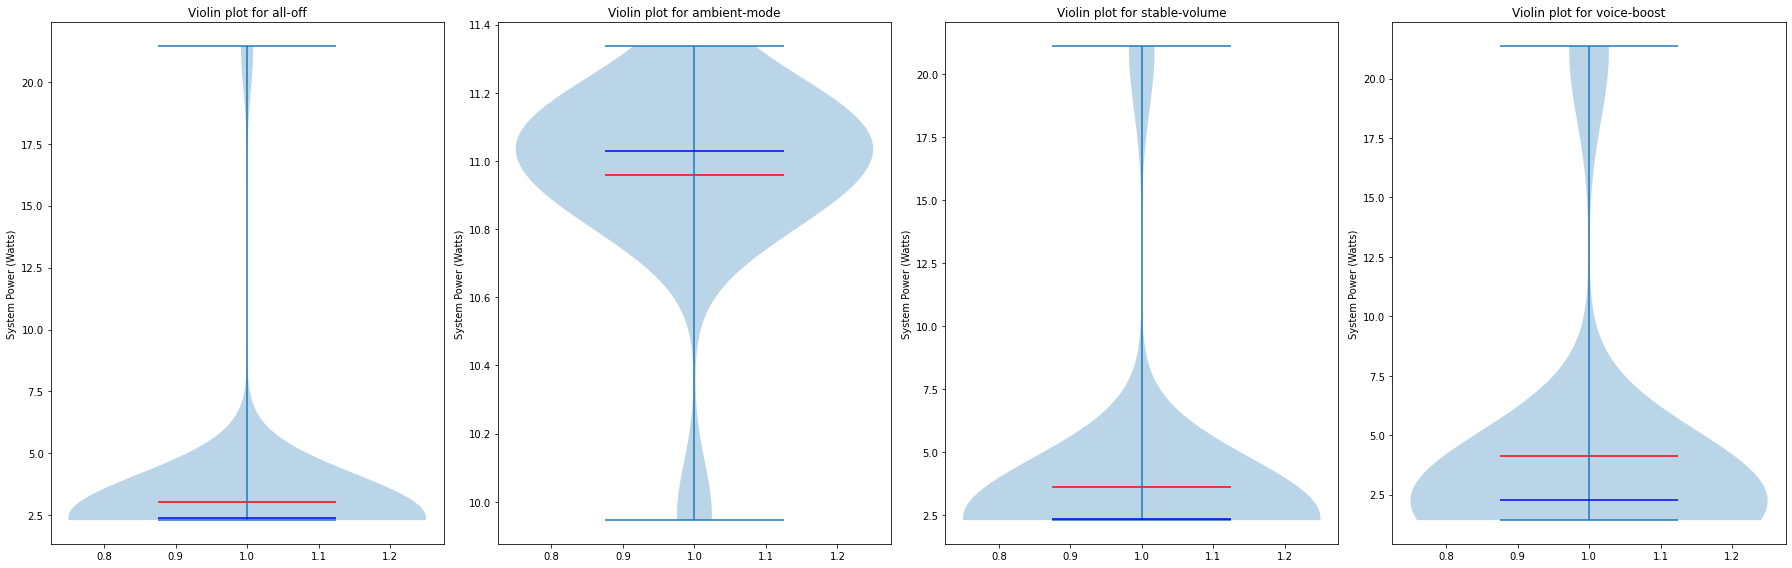

In [100]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(avg_df[f], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

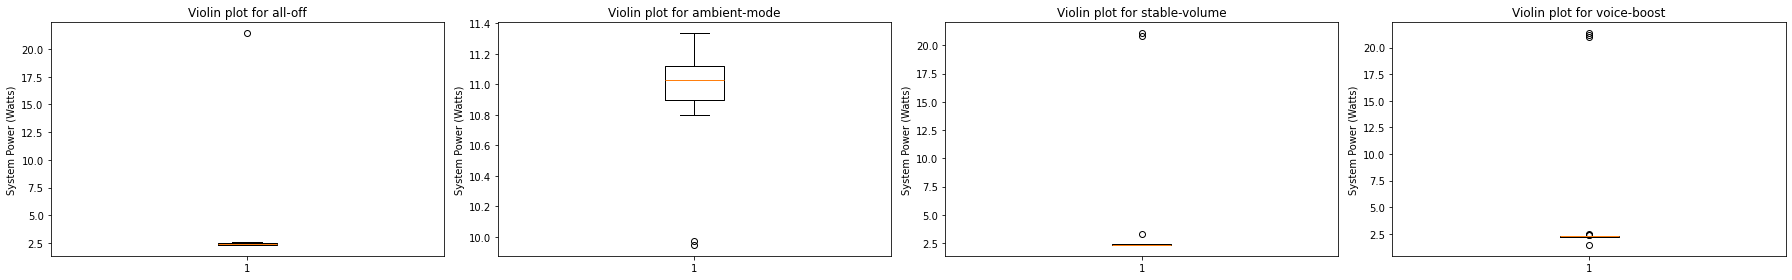

In [101]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(avg_df[f])
    
plt.tight_layout()
plt.show()

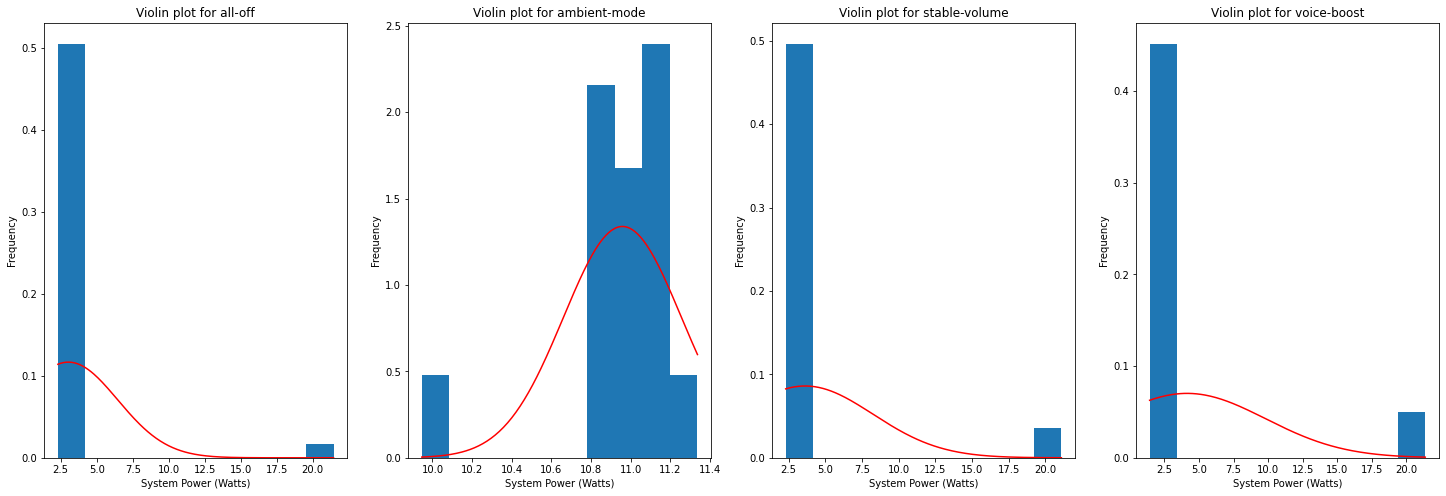

In [102]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(avg_df[f], density=True)
    mu, std = norm.fit(avg_df[f])
    x = np.linspace(avg_df[f].min(), avg_df[f].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

### Normalised Average Results 

In [103]:
for f in avg_df.columns:
    stats, p_val = shapiro(avg_df[f])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.0273120028270188e-11, the data in all-off is NOT NORMAL
With p-val 2.263511532873963e-06, the data in ambient-mode is NOT NORMAL
With p-val 5.945063885626212e-11, the data in stable-volume is NOT NORMAL
With p-val 2.770965956688798e-10, the data in voice-boost is NOT NORMAL


0.8652728199958801


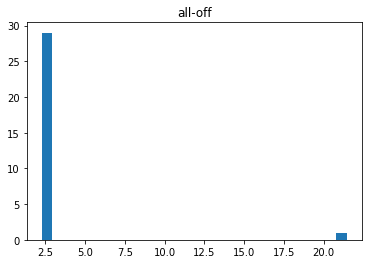

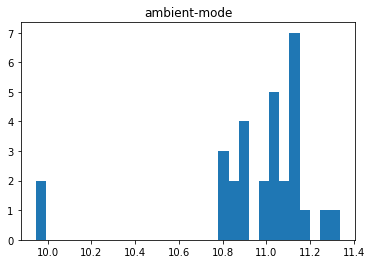

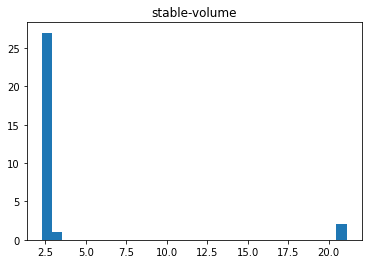

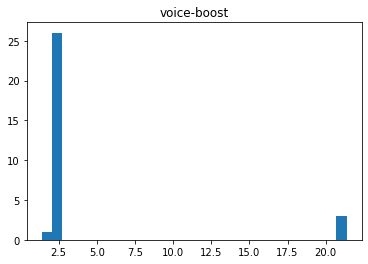

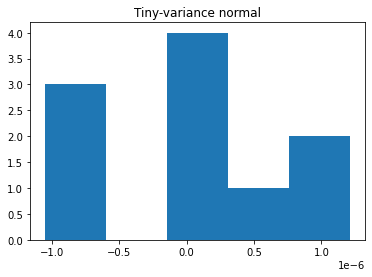

In [192]:
import numpy as np
from scipy.stats import shapiro

x = np.random.normal(loc=0, scale=0.000001, size=10)
stat, p = shapiro(x)
print(p)  # p > 0.05 ≈ normal

for f in avg_df.columns:
    plt.figure()
    plt.hist(avg_df[f], bins=30)
    plt.title(f)
    plt.show()

plt.figure()
plt.hist(x, bins=5)
plt.title("Tiny-variance normal")
plt.show()

In [104]:
# norm_avg_df = {}
# for idx, f in enumerate(QUALITY_DIRECTORIES):
#     mean = avg_df[f].mean()
#     std = avg_df[f].std()
#     outlier = []
#     max_diff = 0
#     print(f"3x std: {3 * std} | mean: {mean}")
#     for idx, val in enumerate(avg_df[f]): 
#         diff = mean - val
#         abs = np.abs(diff)
#         if abs > max_diff: max_diff = abs
#         if abs > 3*std: 
#             print(f"Found outlier at {idx}")
#             outlier.append(idx)

#     print(f"Maximum difference found: {max_diff}")
#     n_df = avg_df[f].drop(index=outlier)
#     norm_avg_df[f] = n_df
#     print("===============================================")
# norm_avg_df = pd.DataFrame(norm_avg_df)
# norm_avg_df

In [105]:
norm_avg_df = {}
for f in QUALITY_DIRECTORIES:
    series = avg_df[f]
    
    # Calculate Quartiles
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds (1.5 is standard, use 3.0 for "extreme" outliers only)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter data
    n_df = series[(series >= lower_bound) & (series <= upper_bound)]
    
    norm_avg_df[f] = n_df
    
    print(f"Range for {f}: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Dropped {len(series) - len(n_df)} outliers")
    print("===============================================")

norm_avg_df = pd.DataFrame(norm_avg_df)
norm_avg_df


Range for all-off: [2.18, 2.65]
Dropped 1 outliers
Range for ambient-mode: [10.56, 11.46]
Dropped 2 outliers
Range for stable-volume: [2.25, 2.47]
Dropped 3 outliers
Range for voice-boost: [2.12, 2.40]
Dropped 7 outliers


,all-off,ambient-mode,stable-volume,voice-boost
0,2.509512,NaN,NaN,2.288264
1,2.560027,10.904376,NaN,2.222439
2,2.385781,10.800656,2.395648,NaN
3,2.363187,10.897482,2.386488,2.257120
4,2.363280,10.814990,2.386653,2.269793
5,2.363049,11.118536,2.352078,2.181522
6,2.506246,11.128990,2.354925,2.222864
7,2.321376,10.894909,2.303528,2.310536
8,2.515282,11.057210,2.371276,2.232363
9,2.321899,11.148391,2.345901,2.298094


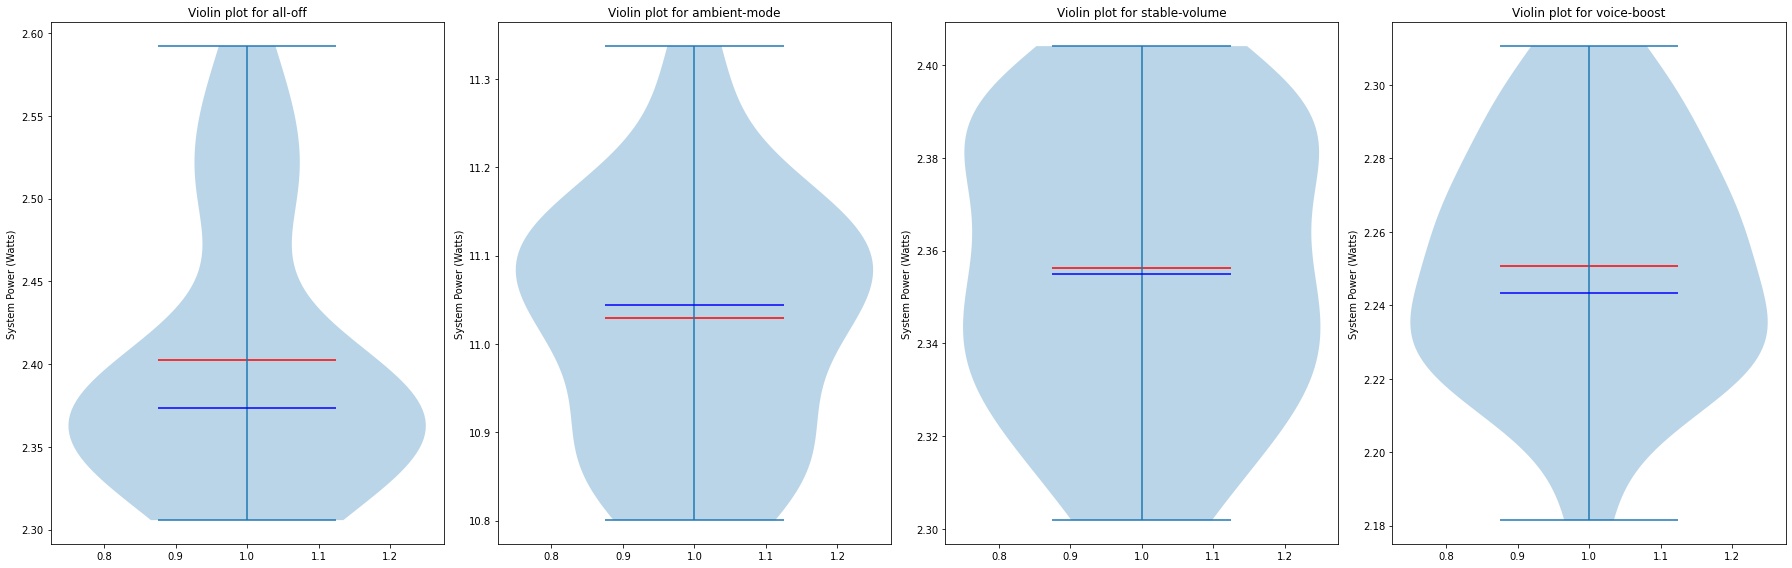

In [106]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(norm_avg_df[f].dropna(), showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()


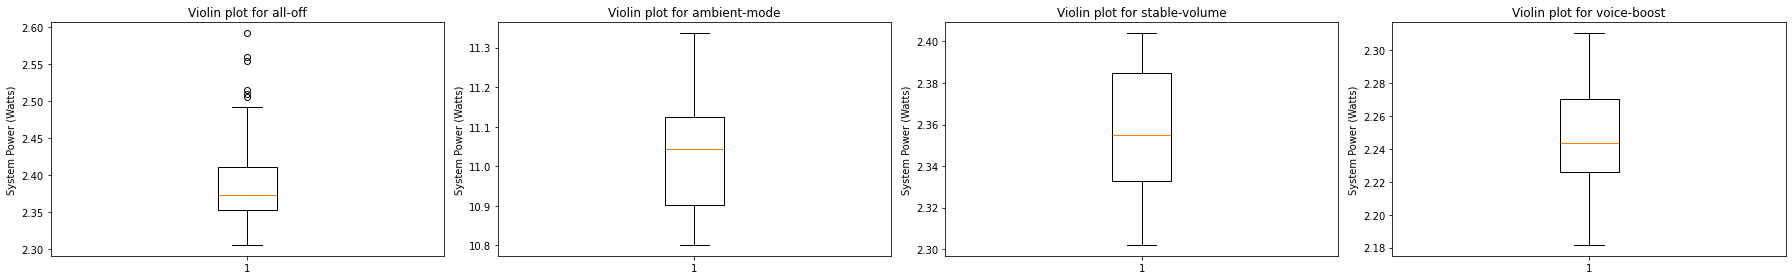

In [107]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(norm_avg_df[f].dropna())
    
plt.tight_layout()
plt.show()

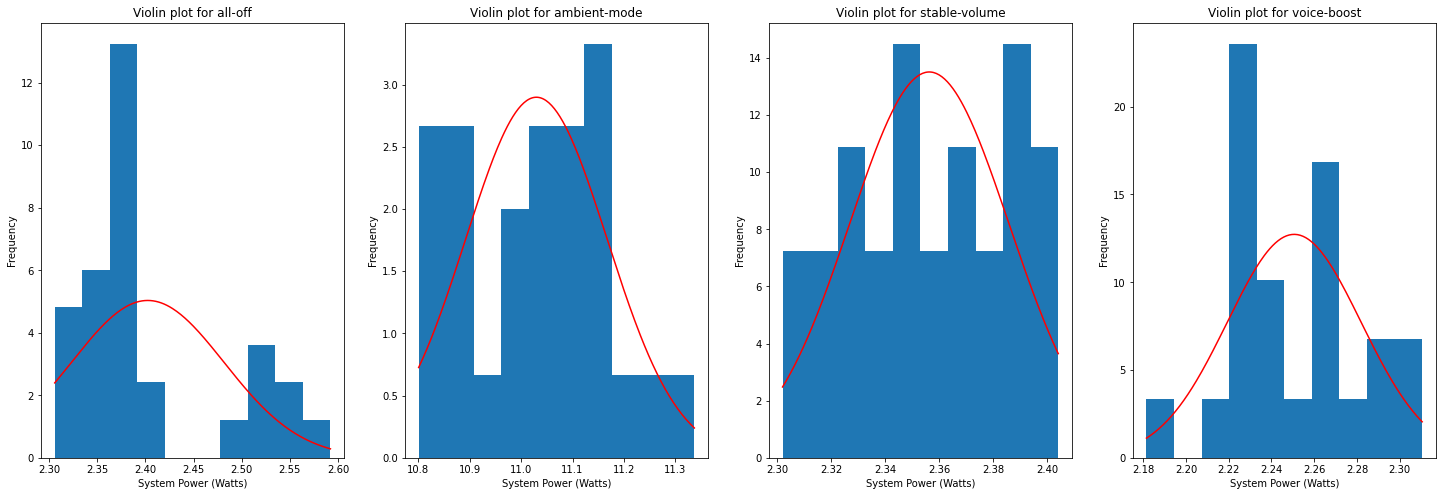

In [108]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(norm_avg_df[f].dropna(), density=True)
    mu, std = norm.fit(norm_avg_df[f].dropna())
    x = np.linspace(norm_avg_df[f].dropna().min(), norm_avg_df[f].dropna().max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

## Initial Median Results

In [109]:
res = {}
for dir in QUALITY_DIRECTORIES: res[dir] = []
for file, df in dataframes.items(): 
    med = df['SYSTEM_POWER (Watts)'].median()
    f = file.split("/")[0]
    res[f].append(med)

med_df = pd.DataFrame(res)
med_df

,all-off,ambient-mode,stable-volume,voice-boost
0,2.459103,7.797339,3.146876,2.213118
1,2.461452,8.393522,20.795269,2.185873
2,2.309629,9.600221,2.273633,1.354360
3,2.327236,9.772090,2.370716,2.171863
4,2.348799,10.762320,2.290750,2.111724
5,2.232711,10.989515,2.262907,2.140203
6,2.391558,12.095822,2.237692,2.153426
7,2.308487,11.135888,2.268544,2.203908
8,2.450016,9.129346,2.332116,2.207793
9,2.303686,10.804743,2.279148,2.150402


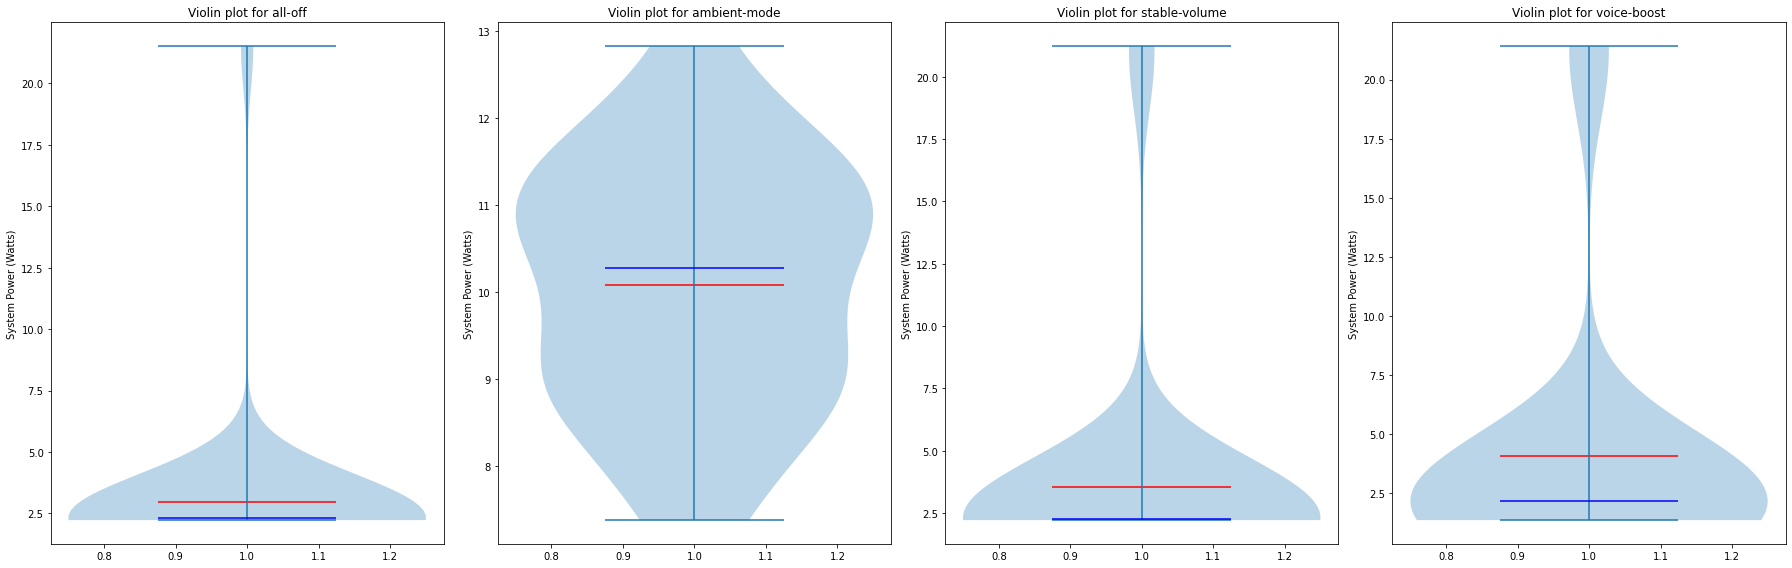

In [110]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(med_df[f], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()

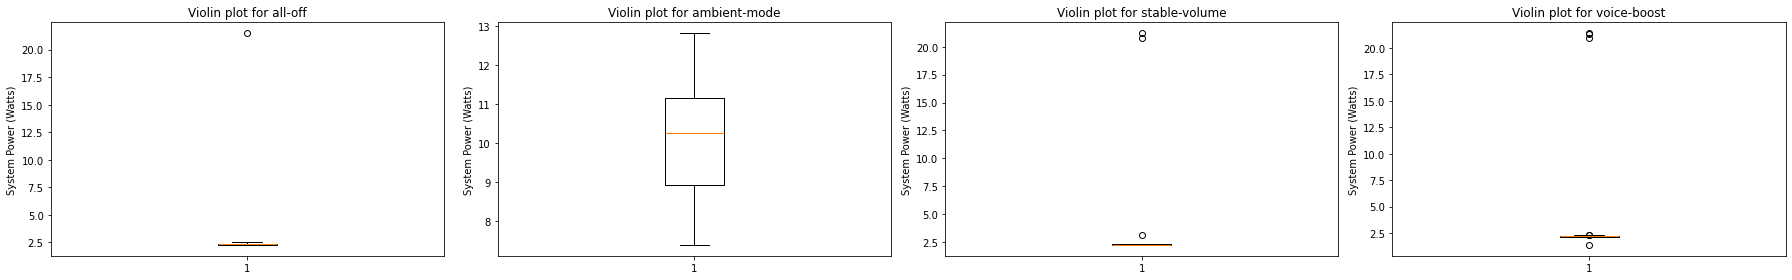

In [111]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(med_df[f])
    
plt.tight_layout()
plt.show()

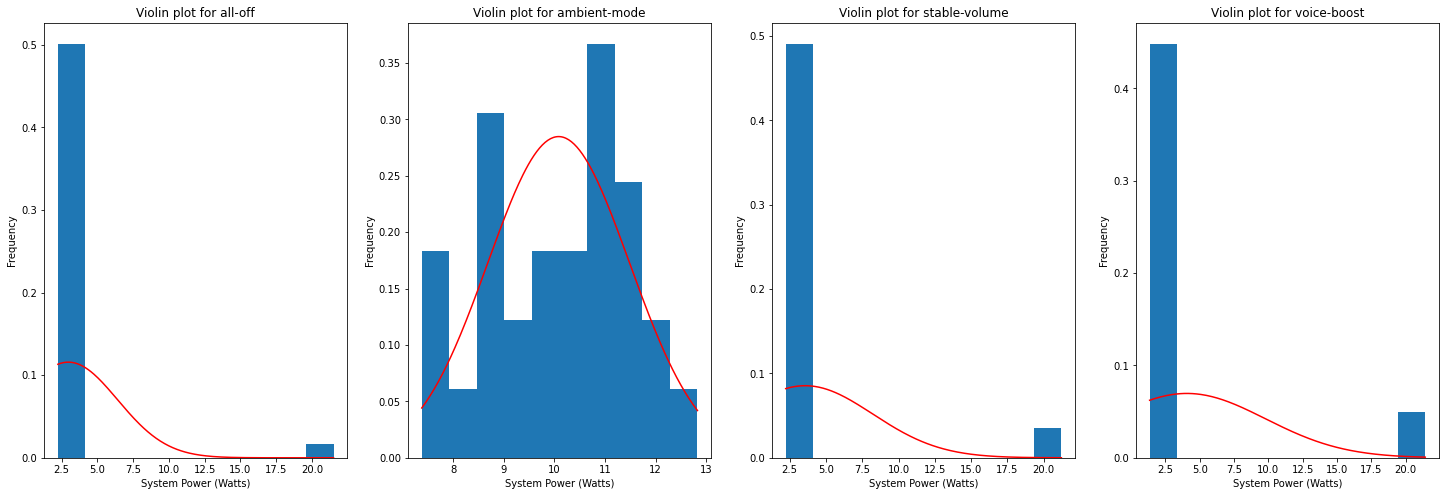

In [112]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(med_df[f], density=True)
    mu, std = norm.fit(med_df[f])
    x = np.linspace(med_df[f].min(), med_df[f].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')

### Normalised Median Results

In [113]:
for f in med_df.columns:
    stats, p_val = shapiro(med_df[f])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.018829291765666e-11, the data in all-off is NOT NORMAL
With p-val 0.5373634696006775, the data in ambient-mode is NORMAL
With p-val 6.005471814285457e-11, the data in stable-volume is NOT NORMAL
With p-val 2.633910589633359e-10, the data in voice-boost is NOT NORMAL


In [114]:
# norm_med_df = {}
# for idx, f in enumerate(QUALITY_DIRECTORIES):
#     mean = med_df[f].mean()
#     std = med_df[f].std()
#     outlier = []
#     max_diff = 0
#     print(f"3x std: {3 * std} | mean: {mean}\nDirectory: {f}")
#     for idx, val in enumerate(med_df[f]): 
#         diff = mean - val
#         abs_diff = np.abs(diff)
#         if abs_diff > max_diff: max_diff = abs_diff
#         if abs_diff > 3*std: 
#             print(f"Found outlier at {idx}: {val}")
#             outlier.append(idx)

#     print(f"Maximum difference found: {max_diff}")
#     n_df = med_df[f].drop(index=outlier)
#     norm_med_df[f] = n_df
#     print("===============================================")
# norm_med_df = pd.DataFrame(norm_med_df)
# norm_med_df

In [115]:
norm_med_df = {}
for f in QUALITY_DIRECTORIES:
    series = med_df[f]
    
    # Calculate Quartiles
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds (1.5 is standard, use 3.0 for "extreme" outliers only)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter data
    n_df = series[(series >= lower_bound) & (series <= upper_bound)]
    
    norm_med_df[f] = n_df
    
    print(f"Range for {f}: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Dropped {len(series) - len(n_df)} outliers")
    print("===============================================")

norm_med_df = pd.DataFrame(norm_med_df)
norm_med_df


Range for all-off: [2.10, 2.55]
Dropped 1 outliers
Range for ambient-mode: [5.59, 14.51]
Dropped 0 outliers
Range for stable-volume: [2.19, 2.40]
Dropped 3 outliers
Range for voice-boost: [2.07, 2.29]
Dropped 6 outliers


,all-off,ambient-mode,stable-volume,voice-boost
0,2.459103,7.797339,NaN,2.213118
1,2.461452,8.393522,NaN,2.185873
2,2.309629,9.600221,2.273633,NaN
3,2.327236,9.772090,2.370716,2.171863
4,2.348799,10.762320,2.290750,2.111724
5,2.232711,10.989515,2.262907,2.140203
6,2.391558,12.095822,2.237692,2.153426
7,2.308487,11.135888,2.268544,2.203908
8,2.450016,9.129346,2.332116,2.207793
9,2.303686,10.804743,2.279148,2.150402


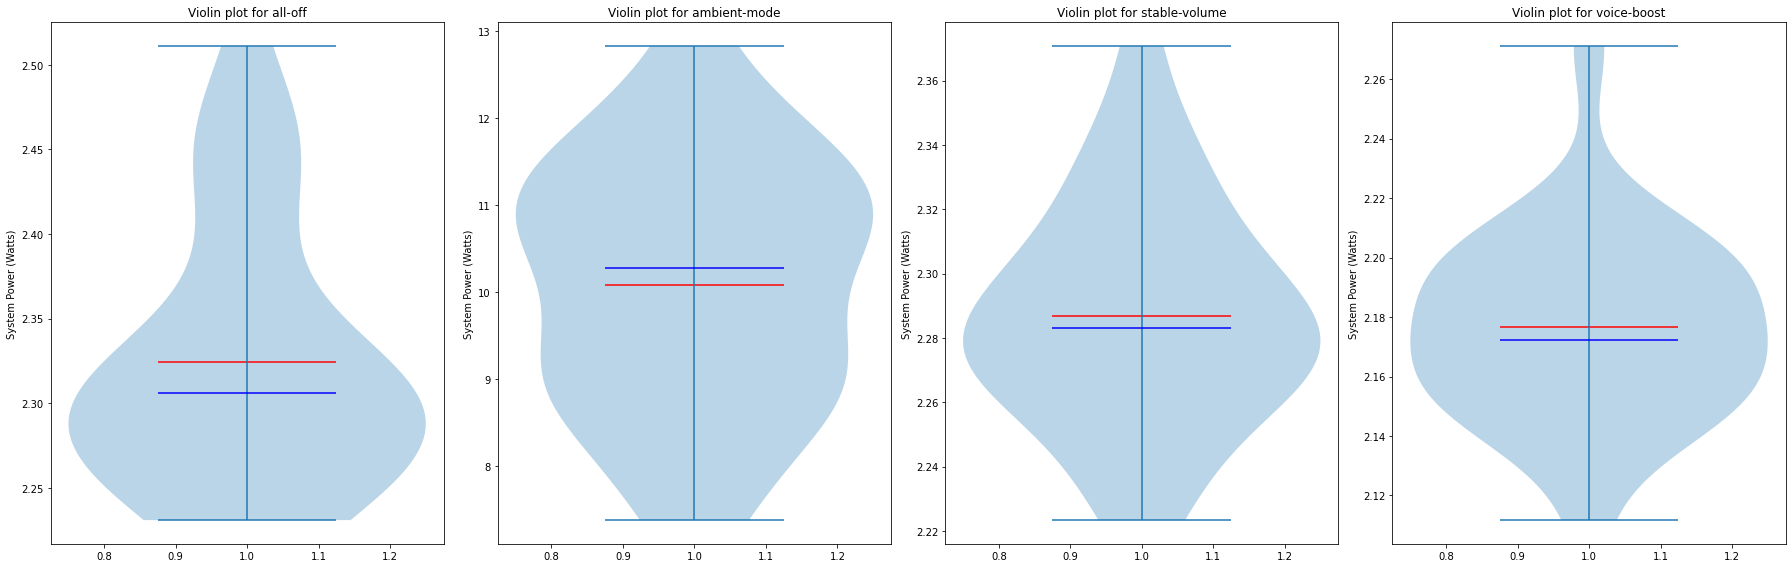

In [116]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(norm_med_df[f].dropna(), showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.tight_layout()
plt.show()


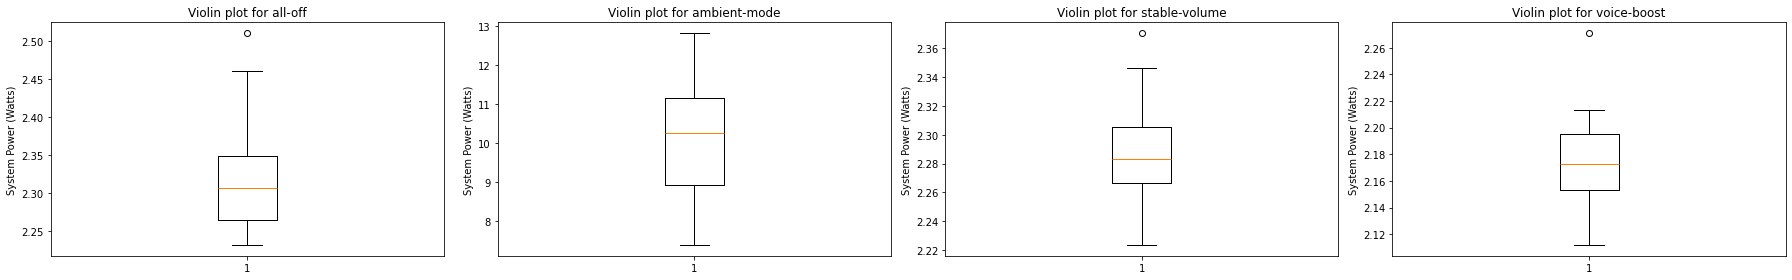

In [117]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(norm_med_df[f].dropna())
    
plt.tight_layout()
plt.show()

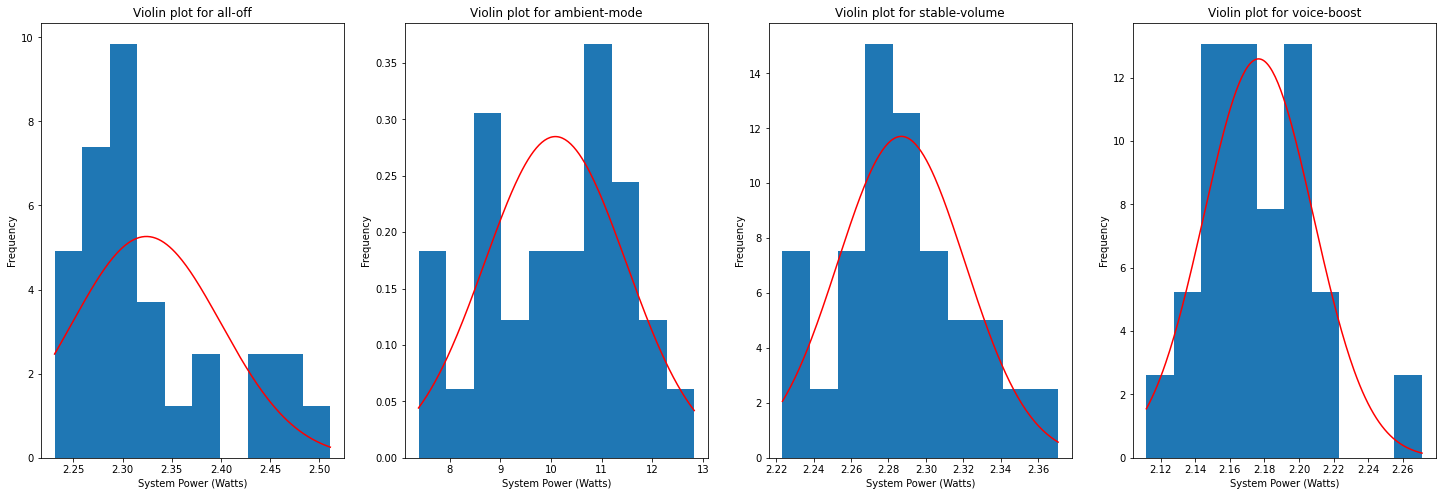

In [118]:
fig, plots = plt.subplots(nrows = 1, 
                            ncols = len(QUALITY_DIRECTORIES),
                            figsize =(25, 2 * len(QUALITY_DIRECTORIES)))
plots = plots.flatten()

for idx, f in enumerate(QUALITY_DIRECTORIES):
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(norm_med_df[f].dropna(), density=True)
    mu, std = norm.fit(norm_med_df[f].dropna())
    x = np.linspace(norm_med_df[f].dropna().min(), norm_med_df[f].dropna().max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')